      Point  Phase  Step  Time [day]   ΣMsf []
50      165      2   164           0  1.425291
1100   1518     41   691           0  1.424819
1050   1468     42   641         200  1.426399
950    1368     43   541         600  1.441191
1000   1418     44   591         400  1.432488
900    1318     45   491         800  1.393022
850    1268     46  1560        1000  1.360181
800    1218     47  1510        1200  1.338830
750    1168     48  1460        1400  1.320330
700    1118     49  1410        1600  1.316016
650    1068     50  1360        1800  1.319437
600    1018     51  1310        2000  1.330781
550     968     52  1260        2200  1.354051
500     918     53  1210        2400  1.386479
450     868     54  1160        2600  1.432827
400     818     55  1110        2700  1.455161
350     768     56  1060        2800  1.481453
300     718     57  1010        2900  1.496210
250     668     58   960        3000  1.516244
200     618     59   910        3100  1.540282
150     568  

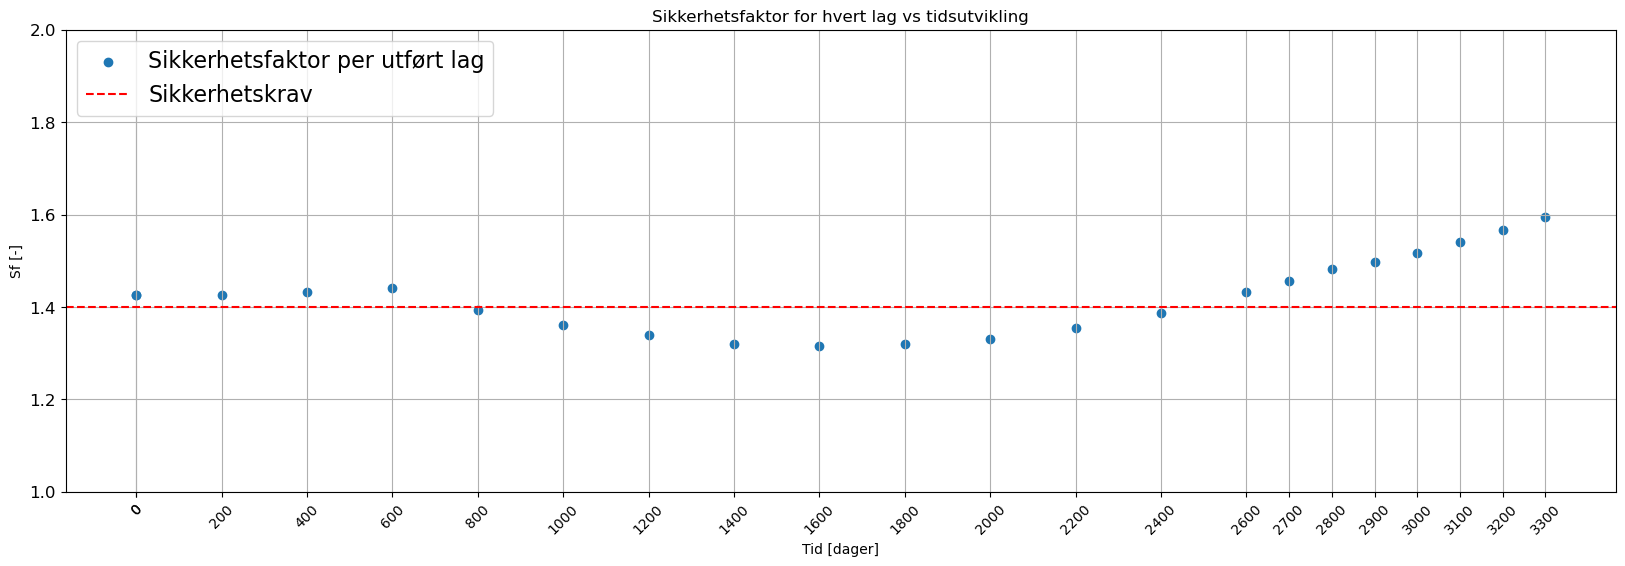

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_excel(r"C:\Users\jdr\OneDriveMulti\SHAREPOINT_Prosjekter\P-10266411-01 Sjøfylling Tåjeodden, Slemmestad - General\Plaxis\Plaxis_resultatverdier_1_10_200dager.xlsx")

# If your columns have spaces, rename for convenience
df = df.rename(columns=lambda x: x.strip())

# For each phase, get the row with the largest step
largest_step_rows = df.loc[df.groupby("Phase")["Step"].idxmax()]
filtered_rows = largest_step_rows[largest_step_rows["ΣMsf []"] != 1]

print(largest_step_rows)
# Plot
plt.figure(figsize=(20, 6))  # Wider plot
plt.scatter(filtered_rows["Time [day]"], filtered_rows["ΣMsf []"], label="Sikkerhetsfaktor per utført lag")
plt.axhline(y=1.4, color="red", linestyle="--", label="Sikkerhetskrav")  # Add red line
plt.xlabel("Tid [dager]")
plt.ylabel("Sf [-]")
plt.title("Sikkerhetsfaktor for hvert lag vs tidsutvikling")
plt.grid(True)
plt.legend(fontsize=16, loc="upper left")
plt.xticks(filtered_rows["Time [day]"], rotation=45, fontsize=10)
plt.yticks(fontsize=12)
plt.ylim(1.0, 2.0)  # Set y-axis limits
plt.show()